In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    make_scorer,
    matthews_corrcoef,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, RobustScaler, StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
plt.style.use("seaborn-v0_8")
pd.set_option("display.max_colwidth", 120)

url = "http://archive.ics.uci.edu/ml/machine-learning-databases/00373/drug_consumption.data"
columns = [
    "id", "age", "gender", "education", "country", "ethnicity",
    "nscore", "escore", "oscore", "ascore", "cscore", "impulsive", "ss",
    "alcohol", "amphet", "amyl", "benzos", "caffeine", "cannabis", "chocolate",
    "cocaine", "crack", "ecstasy", "heroin", "ketamine", "legalh", "lsd",
    "meth", "mushrooms", "nicotine", "semer", "vsa",
]
feature_cols = [
    "age", "gender", "education", "country", "ethnicity",
    "nscore", "escore", "oscore", "ascore", "cscore", "impulsive", "ss",
]
substance_cols = [
    "alcohol", "amphet", "amyl", "benzos", "caffeine", "cannabis",
    "chocolate", "cocaine", "crack", "ecstasy", "heroin", "ketamine",
    "legalh", "lsd", "meth", "mushrooms", "nicotine", "vsa",
]

raw = pd.read_csv(url, header=None, names=columns)
raw = raw[raw["semer"] == "CL0"].reset_index(drop=True)  # usunięcie over-claimers

X_all = raw[feature_cols].copy()

print("Kształt po usunięciu over-claimers:", raw.shape)
print("Liczba cech:", X_all.shape[1])

Kształt po usunięciu over-claimers: (1877, 32)
Liczba cech: 12


In [2]:
y_raw = raw["mushrooms"].copy()
y_raw.value_counts().sort_index()

mushrooms
CL0    982
CL1    208
CL2    259
CL3    272
CL4    114
CL5     39
CL6      3
Name: count, dtype: int64

In [3]:
mask = y_raw != "CL6"
X = X_all.loc[mask].reset_index(drop=True)
y = y_raw.loc[mask].reset_index(drop=True)

label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

print("Rozkład klas po usunięciu CL6:")
display(y.value_counts().sort_index())
print("Klasy:", list(label_encoder.classes_))

Rozkład klas po usunięciu CL6:


mushrooms
CL0    982
CL1    208
CL2    259
CL3    272
CL4    114
CL5     39
Name: count, dtype: int64

Klasy: ['CL0', 'CL1', 'CL2', 'CL3', 'CL4', 'CL5']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (1499, 12) | X_test: (375, 12)


- StratifiedKFold: zachowuje proporcje klas
- kernel: linear (baseline), rbf (nieliniowość), poly (interakcje)
- gamma: próba balansu między biasem a wariancją
- degree = 2, 3: większe stopnie szybko się przeuczają
- C = 0.1, 1, 10, 30: od silnej regularyzacji do mocniejszego dopasowania

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
mcc_scorer = make_scorer(matthews_corrcoef)

base_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(random_state=42, decision_function_shape="ovr")),
])

param_grid = [
    {"svc__kernel": ["linear"], "svc__C": [0.1, 1, 10, 30]},
    {"svc__kernel": ["rbf"], "svc__C": [0.1, 1, 10, 30], "svc__gamma": ["scale", 0.01, 0.1]},
    {"svc__kernel": ["poly"], "svc__C": [0.1, 1, 10], "svc__degree": [2, 3], "svc__gamma": ["scale", 0.1]},
]

scoring = {
    "mcc": mcc_scorer,
    "f1_macro": "f1_macro",
    "balanced_accuracy": "balanced_accuracy",
}

grid = GridSearchCV(
    estimator=base_pipe,
    param_grid=param_grid,
    scoring=scoring,
    refit="mcc",
    cv=cv,
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print("Najlepsze parametry:")
print(grid.best_params_)

Najlepsze parametry:
{'svc__C': 10, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


In [6]:
cv_results = pd.DataFrame(grid.cv_results_).sort_values("rank_test_mcc").reset_index(drop=True)
top_results = cv_results[
    ["params", "mean_test_mcc", "mean_test_f1_macro", "mean_test_balanced_accuracy"]
].head(10).copy()

for c in ["mean_test_mcc", "mean_test_f1_macro", "mean_test_balanced_accuracy"]:
    top_results[c] = top_results[c].round(4)

display(top_results)

,params,mean_test_mcc,mean_test_f1_macro,mean_test_balanced_accuracy
0,"{'svc__C': 10, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.2404,0.2162,0.2516
1,"{'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.2383,0.2296,0.2524
2,"{'svc__C': 1, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.2333,0.2321,0.2516
3,"{'svc__C': 30, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.2333,0.2335,0.2561
4,"{'svc__C': 1, 'svc__kernel': 'linear'}",0.2270,0.1918,0.2417
5,"{'svc__C': 30, 'svc__kernel': 'linear'}",0.2258,0.1915,0.2415
6,"{'svc__C': 10, 'svc__kernel': 'linear'}",0.2258,0.1915,0.2415
7,"{'svc__C': 0.1, 'svc__kernel': 'linear'}",0.2231,0.1908,0.2398
8,"{'svc__C': 1, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.2188,0.1893,0.2348
9,"{'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.2135,0.2699,0.2673


In [7]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

scores_test = pd.DataFrame(
    [
        {
            "accuracy": accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro"),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "mcc": matthews_corrcoef(y_test, y_pred),
        }
    ]
).round(4)

print("Najlepszy MCC w CV:", round(grid.best_score_, 4))
display(scores_test)

Najlepszy MCC w CV: 0.2404


,accuracy,f1_macro,balanced_accuracy,mcc
0,0.5387,0.1981,0.2442,0.2234


- Najlepszy model okazał się nieliniowy (rbf), co sugeruje, że klasy nie są separowalne liniowo w tej przestrzeni.
- Zastosowanie StratifiedKFold było kluczowe, bo klasy są wyraźnie niezbalansowane.
- Mimo strojenia, wyniki są umiarkowane (szczególnie w ujęciu f1_macro), więc problem jest trudny.

In [8]:
svc_step = best_model.named_steps["svc"]
class_ids = svc_step.classes_
class_labels = label_encoder.inverse_transform(class_ids)

report = classification_report(
    y_test,
    y_pred,
    labels=class_ids,
    target_names=class_labels,
    output_dict=True,
    zero_division=0,
)

support_rows = []
for i, cls_name in enumerate(class_labels):
    support_rows.append(
        {
            "class": cls_name,
            "n_support_vectors": int(svc_step.n_support_[i]),
            "test_recall": report[cls_name]["recall"],
            "test_precision": report[cls_name]["precision"],
            "test_f1": report[cls_name]["f1-score"],
            "test_support": int(report[cls_name]["support"]),
        }
    )

support_df = pd.DataFrame(support_rows)
support_df[["test_recall", "test_precision", "test_f1"]] = support_df[
    ["test_recall", "test_precision", "test_f1"]
].round(4)

pearson_corr = support_df["n_support_vectors"].corr(support_df["test_recall"], method="pearson")
spearman_corr = support_df["n_support_vectors"].corr(support_df["test_recall"], method="spearman")

display(support_df)
print(f"Pearson corr(n_support, recall): {pearson_corr:.4f}")
print(f"Spearman corr(n_support, recall): {spearman_corr:.4f}")

,class,n_support_vectors,test_recall,test_precision,test_f1,test_support
0,CL0,396,0.8673,0.6115,0.7173,196
1,CL1,164,0.0238,0.1429,0.0408,42
2,CL2,207,0.0000,0.0000,0.0000,52
3,CL3,213,0.5741,0.3444,0.4306,54
4,CL4,91,0.0000,0.0000,0.0000,23
5,CL5,31,0.0000,0.0000,0.0000,8


Pearson corr(n_support, recall): 0.8394
Spearman corr(n_support, recall): 0.8197


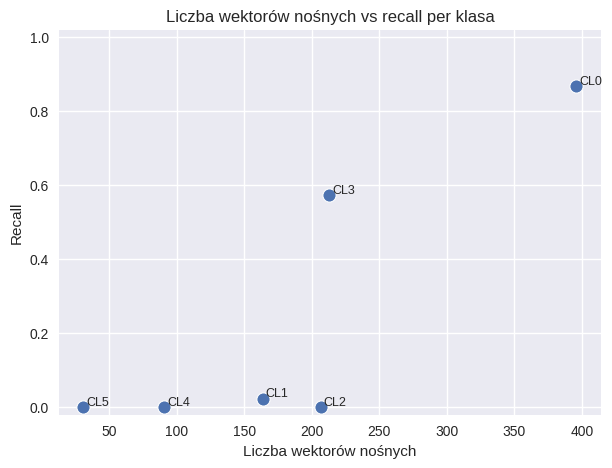

In [9]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=support_df, x="n_support_vectors", y="test_recall", s=90)

for _, row in support_df.iterrows():
    plt.text(row["n_support_vectors"] + 2, row["test_recall"] + 0.005, row["class"], fontsize=9)

plt.title("Liczba wektorów nośnych vs recall per klasa")
plt.xlabel("Liczba wektorów nośnych")
plt.ylabel("Recall")
plt.ylim(-0.02, 1.02)
plt.show()

- W tym eksperymencie korelacja jest dodatnia (większa liczba SV często pojawia się dla klas z wyższym recall).
- To nie oznacza zależności przyczynowej: liczba SV opisuje złożoność granicy i trudność rozdziału klasy, a nie gwarantuje lepszy wynik.
- Klasy mniejszościowe nadal bywają trudne mimo obecności wektorów nośnych.

In [10]:
best_svc_params = {k.replace("svc__", ""): v for k, v in grid.best_params_.items()}

scalers = {
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler(),
    "no_scaling": "passthrough",
}
feature_counts = [2, 3, 4, 5]

fs_rows = []
for scaler_name, scaler in scalers.items():
    for n_features in feature_counts:
        inner_pipe = Pipeline(
            [
                ("scaler", scaler),
                ("svc", SVC(**best_svc_params, random_state=42, decision_function_shape="ovr")),
            ]
        )

        sfs = SequentialFeatureSelector(
            estimator=inner_pipe,
            n_features_to_select=n_features,
            direction="forward",
            scoring=mcc_scorer,
            cv=3,
            n_jobs=-1,
        )
        sfs.fit(X_train, y_train)
        selected = X_train.columns[sfs.get_support()].tolist()

        final_pipe = Pipeline(
            [
                ("scaler", scaler),
                ("svc", SVC(**best_svc_params, random_state=42, decision_function_shape="ovr")),
            ]
        )
        final_pipe.fit(X_train[selected], y_train)
        pred = final_pipe.predict(X_test[selected])

        fs_rows.append(
            {
                "scaler": scaler_name,
                "n_features_to_select": n_features,
                "selected_features": selected,
                "test_accuracy": accuracy_score(y_test, pred),
                "test_f1_macro": f1_score(y_test, pred, average="macro"),
                "test_mcc": matthews_corrcoef(y_test, pred),
            }
        )

fs_results = pd.DataFrame(fs_rows).sort_values(
    ["test_mcc", "test_f1_macro"], ascending=False
).reset_index(drop=True)

fs_results[["test_accuracy", "test_f1_macro", "test_mcc"]] = fs_results[
    ["test_accuracy", "test_f1_macro", "test_mcc"]
].round(4)

display(fs_results)

,scaler,n_features_to_select,selected_features,test_accuracy,test_f1_macro,test_mcc
0,minmax,4,"[age, gender, country, oscore]",0.5600,0.1990,0.2735
1,minmax,5,"[age, gender, country, escore, oscore]",0.5573,0.1958,0.2583
2,robust,5,"[age, gender, education, country, oscore]",0.5520,0.1973,0.2557
3,standard,4,"[age, country, oscore, ss]",0.5413,0.1926,0.2396
4,no_scaling,4,"[age, education, country, oscore]",0.5413,0.1913,0.2362
5,standard,5,"[age, country, oscore, impulsive, ss]",0.5360,0.1909,0.2342
6,robust,4,"[age, education, country, oscore]",0.5413,0.1903,0.2337
7,no_scaling,5,"[age, education, country, oscore, ss]",0.5333,0.1896,0.2271
8,robust,3,"[age, country, oscore]",0.5333,0.1865,0.2194
9,no_scaling,3,"[age, country, oscore]",0.5360,0.1886,0.2158


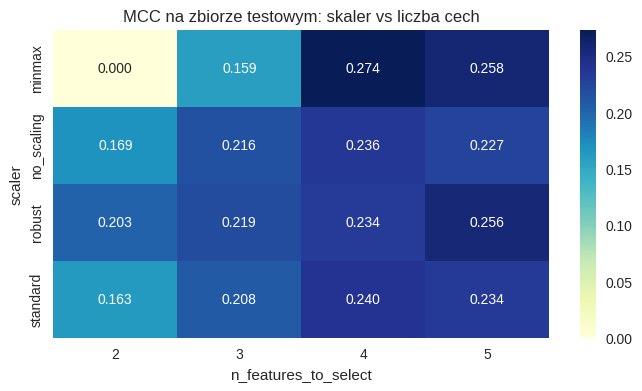

In [11]:
heat = fs_results.pivot(index="scaler", columns="n_features_to_select", values="test_mcc")
plt.figure(figsize=(8, 4))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("MCC na zbiorze testowym: skaler vs liczba cech")
plt.xlabel("n_features_to_select")
plt.ylabel("scaler")
plt.show()

- Wyniki zależą od skalera i liczby cech; najlepszy wariant nie jest taki sam dla wszystkich konfiguracji.
- W tym eksperymencie najlepsze MCC daje konfiguracja z większą liczbą cech (nie 2), co sugeruje utratę informacji przy bardzo agresywnej redukcji.

Najlepsza para cech (n=2): ['age', 'country']
Skaler: robust


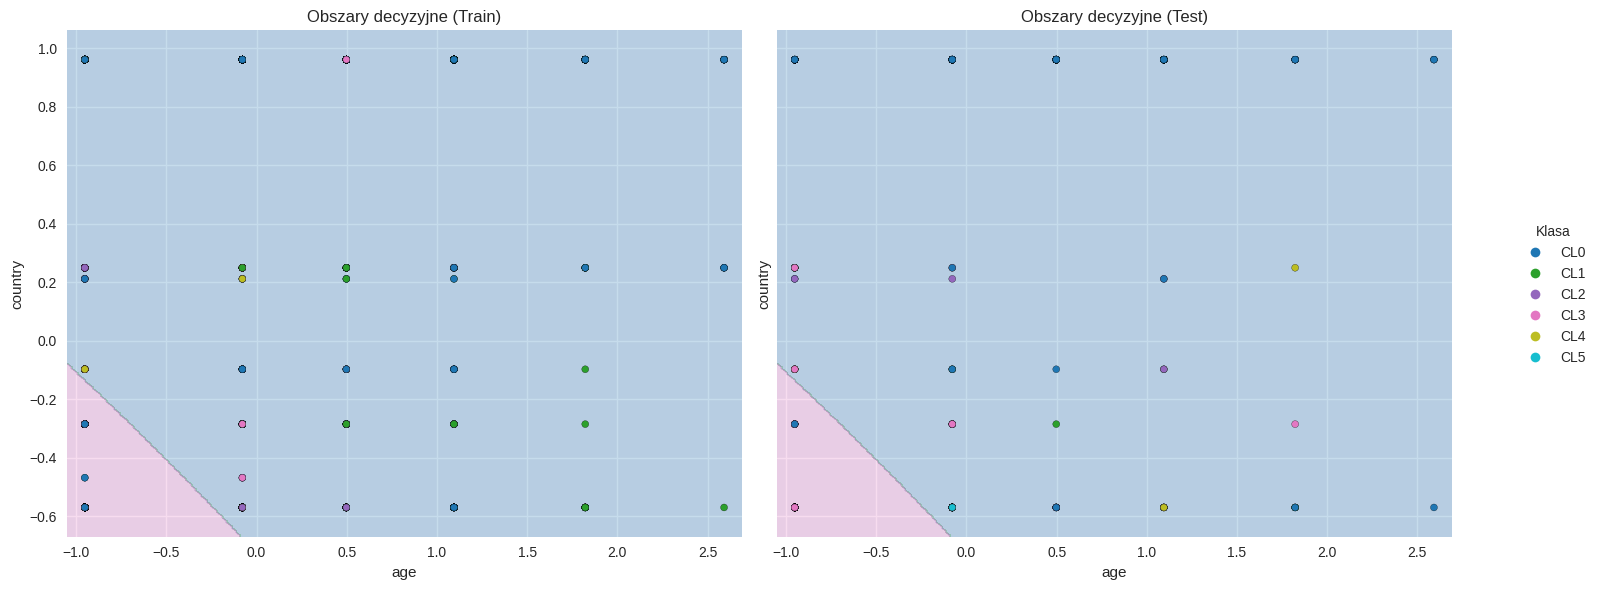

In [12]:
best_n2 = (
    fs_results[fs_results["n_features_to_select"] == 2]
    .sort_values(["test_mcc", "test_f1_macro"], ascending=False)
    .iloc[0]
)

best_pair = best_n2["selected_features"]
best_pair_scaler = best_n2["scaler"]
scaler_obj = scalers[best_pair_scaler]

print("Najlepsza para cech (n=2):", best_pair)
print("Skaler:", best_pair_scaler)

X_train_2 = X_train[best_pair].copy()
X_test_2 = X_test[best_pair].copy()

model_2d = Pipeline(
    [
        ("scaler", scaler_obj),
        ("svc", SVC(**best_svc_params, random_state=42, decision_function_shape="ovr")),
    ]
)
model_2d.fit(X_train_2, y_train)

x_min = min(X_train_2.iloc[:, 0].min(), X_test_2.iloc[:, 0].min()) - 0.1
x_max = max(X_train_2.iloc[:, 0].max(), X_test_2.iloc[:, 0].max()) + 0.1
y_min = min(X_train_2.iloc[:, 1].min(), X_test_2.iloc[:, 1].min()) - 0.1
y_max = max(X_train_2.iloc[:, 1].max(), X_test_2.iloc[:, 1].max()) + 0.1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 350), np.linspace(y_min, y_max, 350))
grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=best_pair)
zz = model_2d.predict(grid_points).reshape(xx.shape)

classes = np.unique(y_train)
n_classes = len(classes)
cmap = plt.get_cmap("tab10", n_classes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
for ax, X_split, y_split, title in [
    (axes[0], X_train_2, y_train, "Train"),
    (axes[1], X_test_2, y_test, "Test"),
]:
    ax.contourf(
        xx,
        yy,
        zz,
        levels=np.arange(-0.5, n_classes + 0.5, 1),
        cmap=cmap,
        alpha=0.25,
    )
    ax.scatter(
        X_split.iloc[:, 0],
        X_split.iloc[:, 1],
        c=y_split,
        cmap=cmap,
        s=25,
        edgecolor="k",
        linewidth=0.2,
    )
    ax.set_title(f"Obszary decyzyjne ({title})")
    ax.set_xlabel(best_pair[0])
    ax.set_ylabel(best_pair[1])

handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=label_encoder.inverse_transform([cls])[0],
        markerfacecolor=cmap(cls),
        markeredgecolor="k",
        markersize=7,
    )
    for cls in classes
]
fig.legend(handles=handles, loc="center right", title="Klasa")
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

- Dla 2 cech obszary mocno się nakładają, a granice są nieregularne.
- To potwierdza, że reprezentacja 2D jest zbyt uboga dla tego wieloklasowego problemu.

In [13]:
svc_cv_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("svc", SVC(**best_svc_params, random_state=42, decision_function_shape="ovr")),
    ]
)
linear_cv_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("linear_svc", LinearSVC()),
    ]
)

svc_scores = cross_val_score(svc_cv_pipe, X_train, y_train, cv=cv, scoring=mcc_scorer, n_jobs=-1)
linear_scores = cross_val_score(linear_cv_pipe, X_train, y_train, cv=cv, scoring=mcc_scorer, n_jobs=-1)

compare_df = pd.DataFrame(
    [
        {
            "model": "Best SVC (z GridSearchCV)",
            "mcc_mean": np.mean(svc_scores),
            "mcc_std": np.std(svc_scores),
        },
        {
            "model": "LinearSVC (domyślny)",
            "mcc_mean": np.mean(linear_scores),
            "mcc_std": np.std(linear_scores),
        },
    ]
).round(4)

display(compare_df)

,model,mcc_mean,mcc_std
0,Best SVC (z GridSearchCV),0.2404,0.0188
1,LinearSVC (domyślny),0.2479,0.0244


- W tym zestawie wyników `LinearSVC` jest porównywalny lub nieco lepszy od strojonego SVC-RBF.
- To sugeruje, że zwiększanie złożoności jądra nie zawsze przekłada się na poprawę MCC.

SVC jest sensownym punktem odniesienia, ale nie jest modelem idealnym dla tego problemu.
- Plus: stabilne działanie i sensowne wyniki globalne.
- Minus: słaba jakość dla części klas (szczególnie mniejszościowych), co obniża miary makro.
- Dlatego warto porównywać także z innymi metodami (np. modele drzewiaste, boosting, klasyfikatory liniowe z regularyzacją).

In [14]:
sub_grid = [
    {"svc__kernel": ["linear"], "svc__C": [0.1, 1, 10]},
    {"svc__kernel": ["rbf"], "svc__C": [0.1, 1, 10], "svc__gamma": ["scale", 0.1]},
]

substance_rows = []
for substance in substance_cols:
    y_sub_raw = raw[substance].copy()
    counts = y_sub_raw.value_counts()
    keep_classes = counts[counts >= 5].index  # stabilność dla CV
    mask_sub = y_sub_raw.isin(keep_classes)

    X_sub = X_all.loc[mask_sub].reset_index(drop=True)
    y_sub = y_sub_raw.loc[mask_sub].reset_index(drop=True)

    if y_sub.nunique() < 2:
        continue

    le_sub = LabelEncoder()
    y_sub_enc = le_sub.fit_transform(y_sub)

    cv_sub = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    pipe_sub = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("svc", SVC(random_state=42, decision_function_shape="ovr")),
        ]
    )

    gs_sub = GridSearchCV(
        estimator=pipe_sub,
        param_grid=sub_grid,
        scoring=mcc_scorer,
        refit=True,
        cv=cv_sub,
        n_jobs=-1,
    )
    gs_sub.fit(X_sub, y_sub_enc)

    substance_rows.append(
        {
            "substance": substance,
            "n_samples": len(X_sub),
            "n_classes": y_sub.nunique(),
            "best_cv_mcc": gs_sub.best_score_,
            "best_params": gs_sub.best_params_,
        }
    )

substance_results = pd.DataFrame(substance_rows).sort_values("best_cv_mcc", ascending=False).reset_index(drop=True)
substance_results["best_cv_mcc"] = substance_results["best_cv_mcc"].round(4)

display(substance_results.head(10))

,substance,n_samples,n_classes,best_cv_mcc,best_params
0,legalh,1877,7,0.3223,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,lsd,1877,7,0.2904,"{'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}"
2,cannabis,1877,7,0.2800,"{'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}"
3,mushrooms,1874,6,0.2433,"{'svc__C': 1, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}"
4,cocaine,1877,7,0.1980,"{'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}"
5,ecstasy,1877,7,0.1956,"{'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}"
6,nicotine,1877,7,0.1862,"{'svc__C': 1, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}"
7,amyl,1874,6,0.1493,"{'svc__C': 10, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}"
8,benzos,1877,7,0.1471,"{'svc__C': 10, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}"
9,amphet,1877,7,0.1401,"{'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}"


In [15]:
best_substance = substance_results.iloc[0]
print("Używka z najwyższym MCC:", best_substance["substance"])
print("MCC:", best_substance["best_cv_mcc"])
print("Najlepsze parametry:", best_substance["best_params"])

Używka z najwyższym MCC: legalh
MCC: 0.3223
Najlepsze parametry: {'svc__C': 1, 'svc__kernel': 'linear'}


- W tym eksperymencie najlepszy wynik uzyskała używka z pierwszego miejsca rankingu powyżej.
- Pętla po wszystkich `y` pozwala obiektywnie porównać trudność poszczególnych celów predykcji.